In [1]:
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import glob
from matplotlib.ticker import ScalarFormatter, LogFormatter, FuncFormatter
import sys

sys.path.insert(1, '../')
from Functions import *
import MetricMapping

# Access the mappings:
type_mapping = MetricMapping.type_mapping
name_mapping = MetricMapping.name_mapping

In [2]:
datadir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Data/IntermediateFiles/'
figdir = '/scratch/hydro4/users/kv25483/MetricEvaluation/Figures/'

In [3]:
resolutions = ['dblnorm']

## Prepare the data
### Get the data

In [4]:
just_5m = pd.read_csv(datadir+"/Just5m.csv")

### Get just the raw and dblnorm columns

### Get a list of metrics

In [5]:
metrics = list(name_mapping.keys())
categorical_metrics = ['3rd_ARR',  '3rd_rcg',  '3rd_w_peak', '4th_w_peak', '5th_w_peak', 'third_ppr', '3rd_w_most', 
                       '4th_w_most', '5th_w_most']
continuous_metrics = [metric for metric in list(type_mapping.keys()) if metric not in categorical_metrics]

### Calculate statistics on the data

In [6]:
summary_df = compute_metric_sensitivity_bynormalisation(df=just_5m,
    continuous_metrics=continuous_metrics,
    categorical_metrics=categorical_metrics,
    resolutions =resolutions)
summary_df["type2"] = summary_df["metric"].map(type_mapping)

dblnorm
missing column I30_raw or I30_dblnorm
missing column norm_time_std_raw or norm_time_std_dblnorm


### Get versions of the data split by metric type`

In [7]:
df_continuous = summary_df[summary_df["type"] != "categorical"]
# df_continuous = df_continuous[df_continuous['metric'] != 'mean_intensity'].copy()
unique_metrics_continuous = df_continuous['metric'].unique().tolist()

df_categorical = summary_df[summary_df["type"] == "categorical"]
unique_metrics_categorical = df_categorical['metric'].unique().tolist()

## Plotting
### Scatter plot

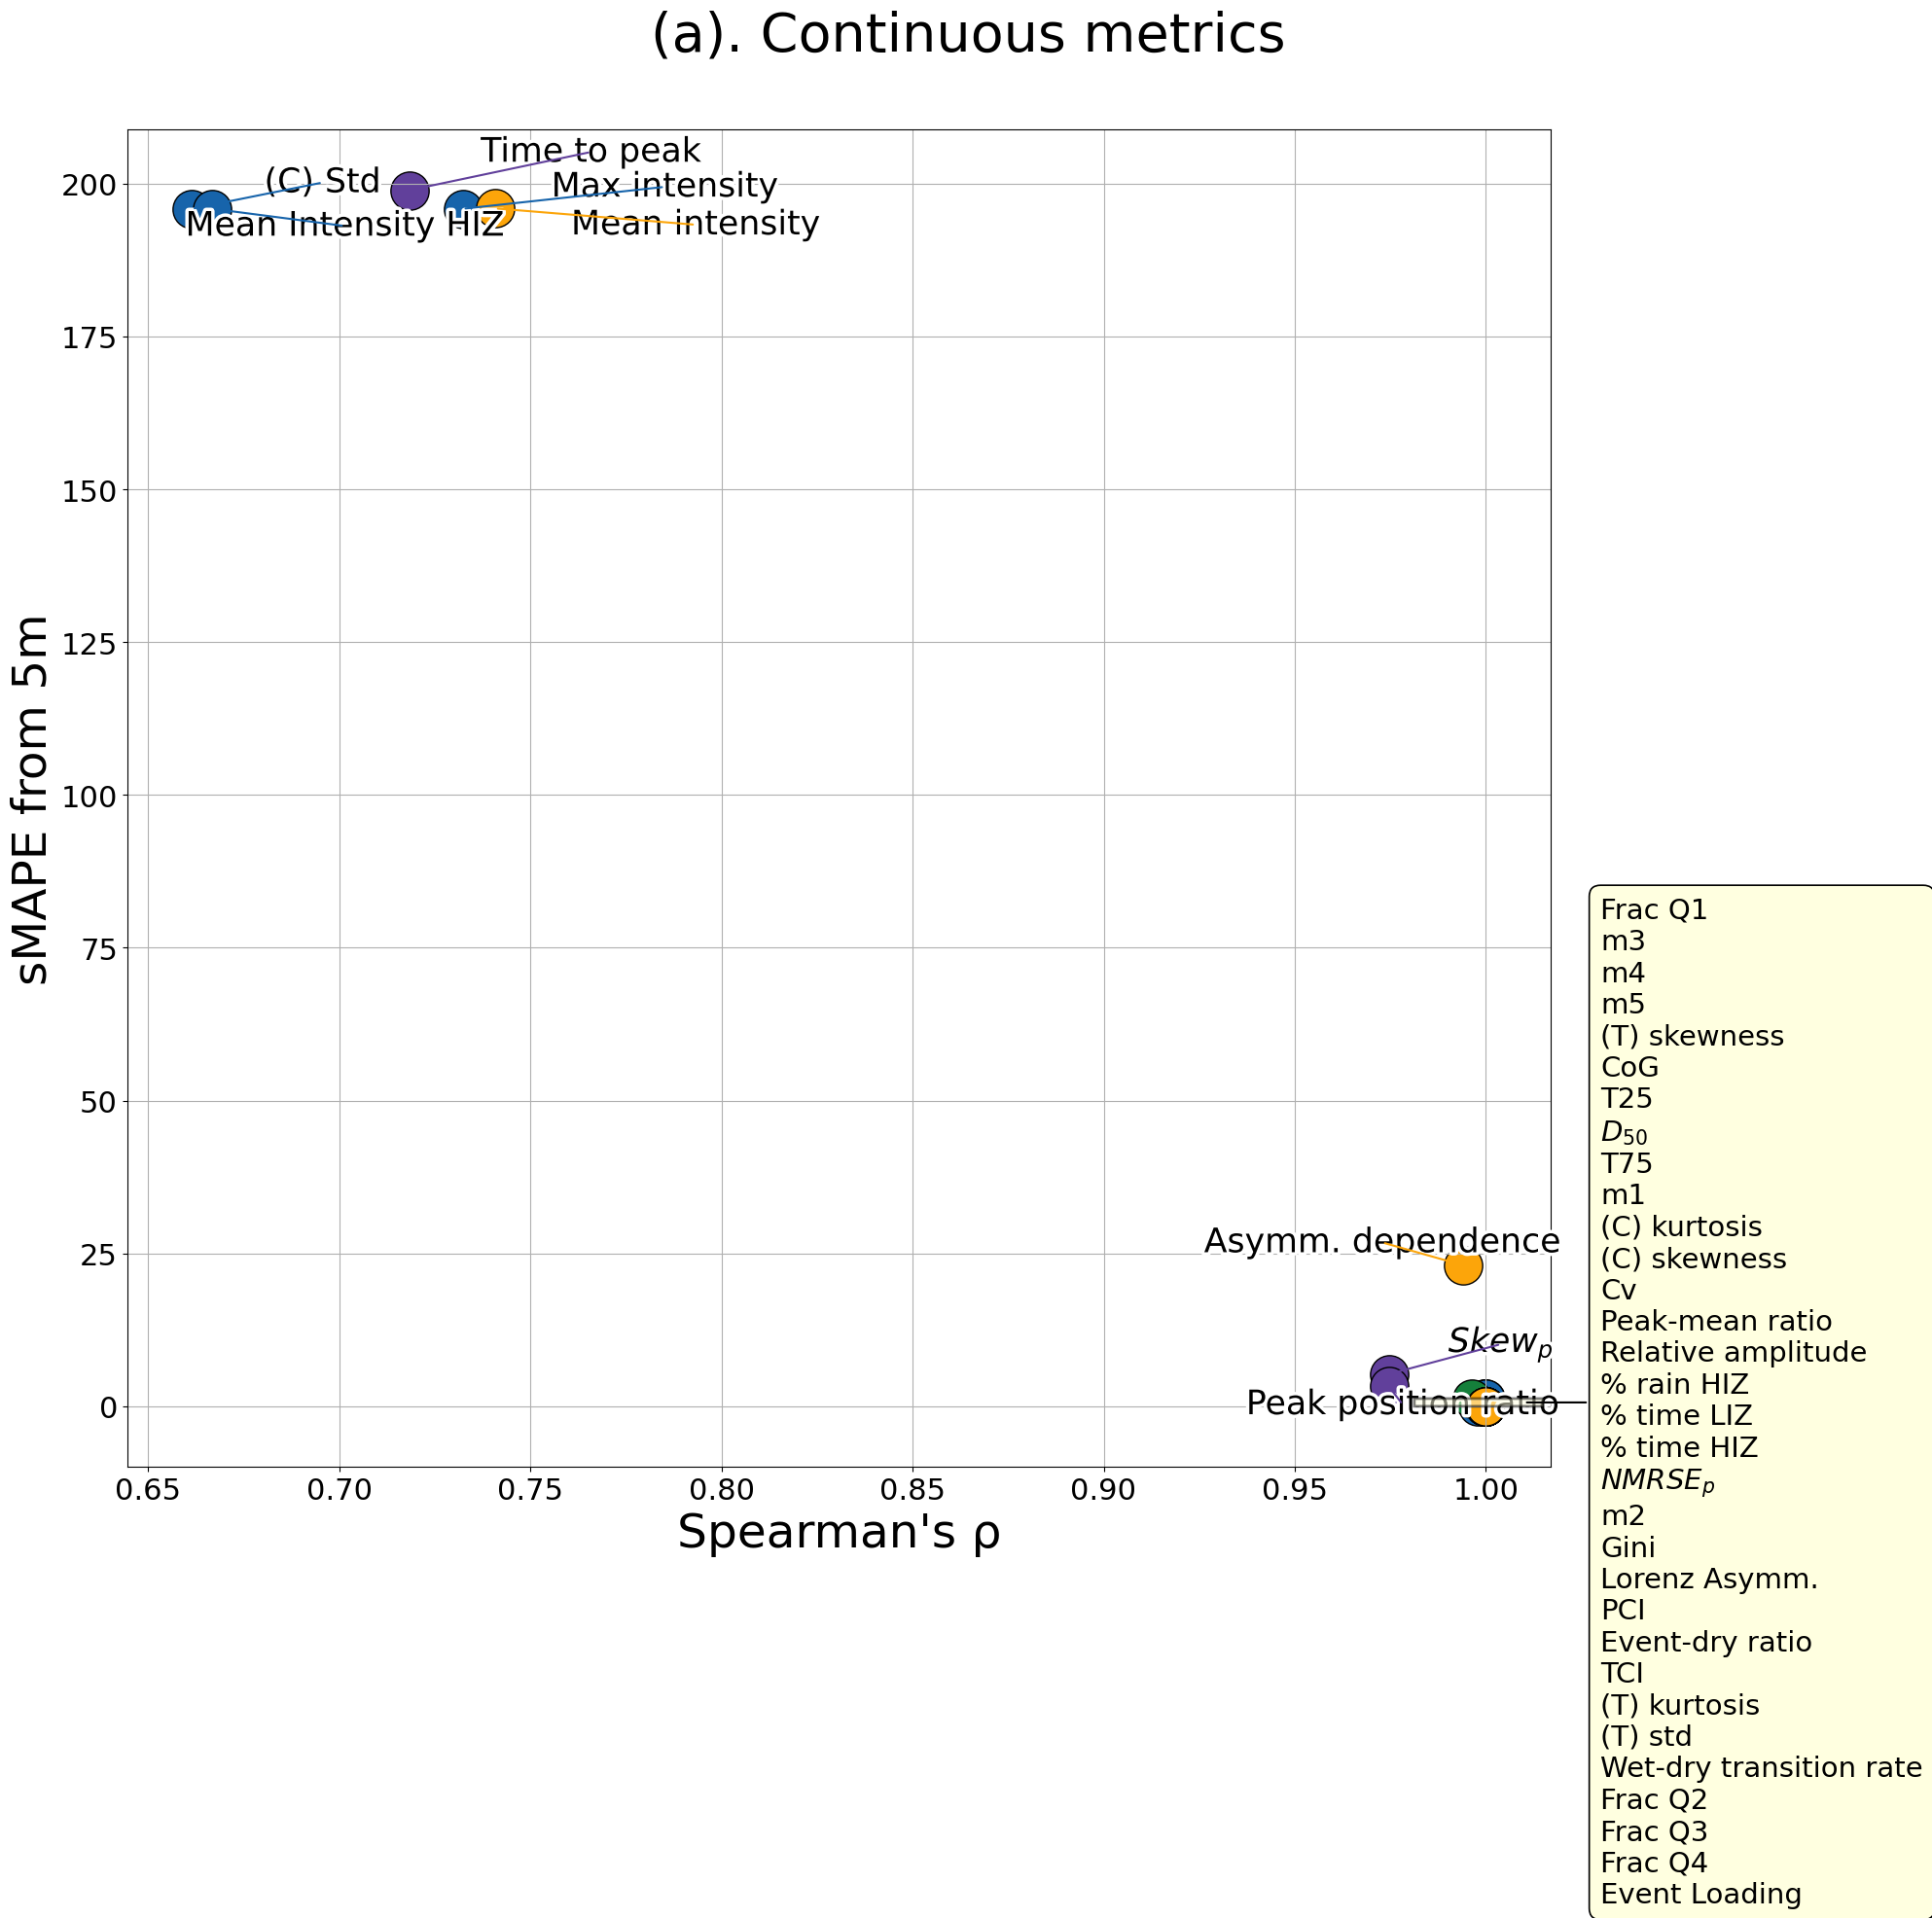

In [8]:
import matplotlib.patheffects as pe

size = 800
labelsize = 25
marker = 'o'

# Points to label directly on main plot
mask_label   = ~((df_continuous["rank_corr"] > 0.05) & (df_continuous["val_diff"] <2))
# Everything else goes into the text list
mask_cluster = ~mask_label

df_label   = df_continuous[mask_label]
df_cluster = df_continuous[mask_cluster]

fig, ax = plt.subplots(figsize=(20, 20))

original_positions = []
face_colors = []
texts = []

# --- Plot all points ---
for _, row in df_continuous.iterrows():
    face_color = type_color_map_3[row['type2']][1]
    ax.scatter(
        row["rank_corr"], row["val_diff"],
        facecolor=face_color, edgecolor="black",
        marker=marker, s=size, alpha=1)

ax.tick_params(axis='both', which='major', labelsize=22)

# --- Label main plot points ---
for _, row in df_label.iterrows():
    face_color = type_color_map_3[row['type2']][1]
    # Add small random offset so adjust_text starts with spread-out positions

    txt = ax.text(
        row["rank_corr"] + 0.02,
        row["val_diff"] + 0.6,
        name_mapping[row["metric"]],
        fontsize=labelsize, color='black',
        ha="left", va="bottom")
    txt.set_path_effects([pe.withStroke(linewidth=5, foreground="white")])
    texts.append(txt)
    original_positions.append((row["rank_corr"], row["val_diff"]))
    face_colors.append(face_color)

adjust_text(
    texts,
    x=df_label["rank_corr"].values,
    y=df_label["val_diff"].values,
    ax=ax,
    only_move={'text': 'y'},
    force_text=0.5,
    force_points=1.0,
    expand_text=(2.2, 2.2),
    expand_points=(3.0, 3.0),
    lim=500,
    #arrowprops=dict(arrowstyle="-", color='grey', lw=1),
)

for txt, (x0, y0), face_color in zip(texts, original_positions, face_colors):
    x1, y1 = txt.get_position()
    ax.annotate("", xy=(x0, y0), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-", color=face_color, lw=1.5))

# --- Draw box around dense cluster and list names beside it ---
if len(df_cluster) > 0:
    pad = 0.01
    cx0 = df_cluster["rank_corr"].min() - pad
    cx1 = df_cluster["rank_corr"].max() + pad
    cy0 = df_cluster["val_diff"].min() # - pad
    cy1 = df_cluster["val_diff"].max()  + pad

    cluster_rect = patches.FancyBboxPatch(
        (cx0, cy0), cx1 - cx0, cy1 - cy0,
        boxstyle="round,pad=0.005",
        linewidth=2, edgecolor='black',
        facecolor='lightyellow', alpha=0.5, zorder=3)
    ax.add_patch(cluster_rect)

    # Build stacked name list with coloured dots
    cluster_names = "\n".join(
        [name_mapping[r["metric"]] for _, r in df_cluster.iterrows()])

#     cx0 =0.6
#     cx1 =0.8
#     cy0 =75
#     cy1 =100
    
    ax.annotate(
        cluster_names,
        xy=(cx1, (cy0 + cy1) / 2),
        xytext=(cx1 + 0.02, (cy0 + cy1) / 2),
        fontsize=labelsize - 4,
        va='center', ha='left',
        arrowprops=dict(arrowstyle="-", color='black', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='black', linewidth=1.2))

# --- Main axes ---
ax.set_xlabel("Spearman's ρ", fontsize=35)
ax.set_ylabel("sMAPE from 5m", fontsize=35)
ax.grid(True)

fig.suptitle("(a). Continuous metrics", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig.savefig(
    figdir + "CompareNormalisation/Scatter_continuous_dblnorm.png",
    dpi=300,
    facecolor='white',
    bbox_inches='tight')

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


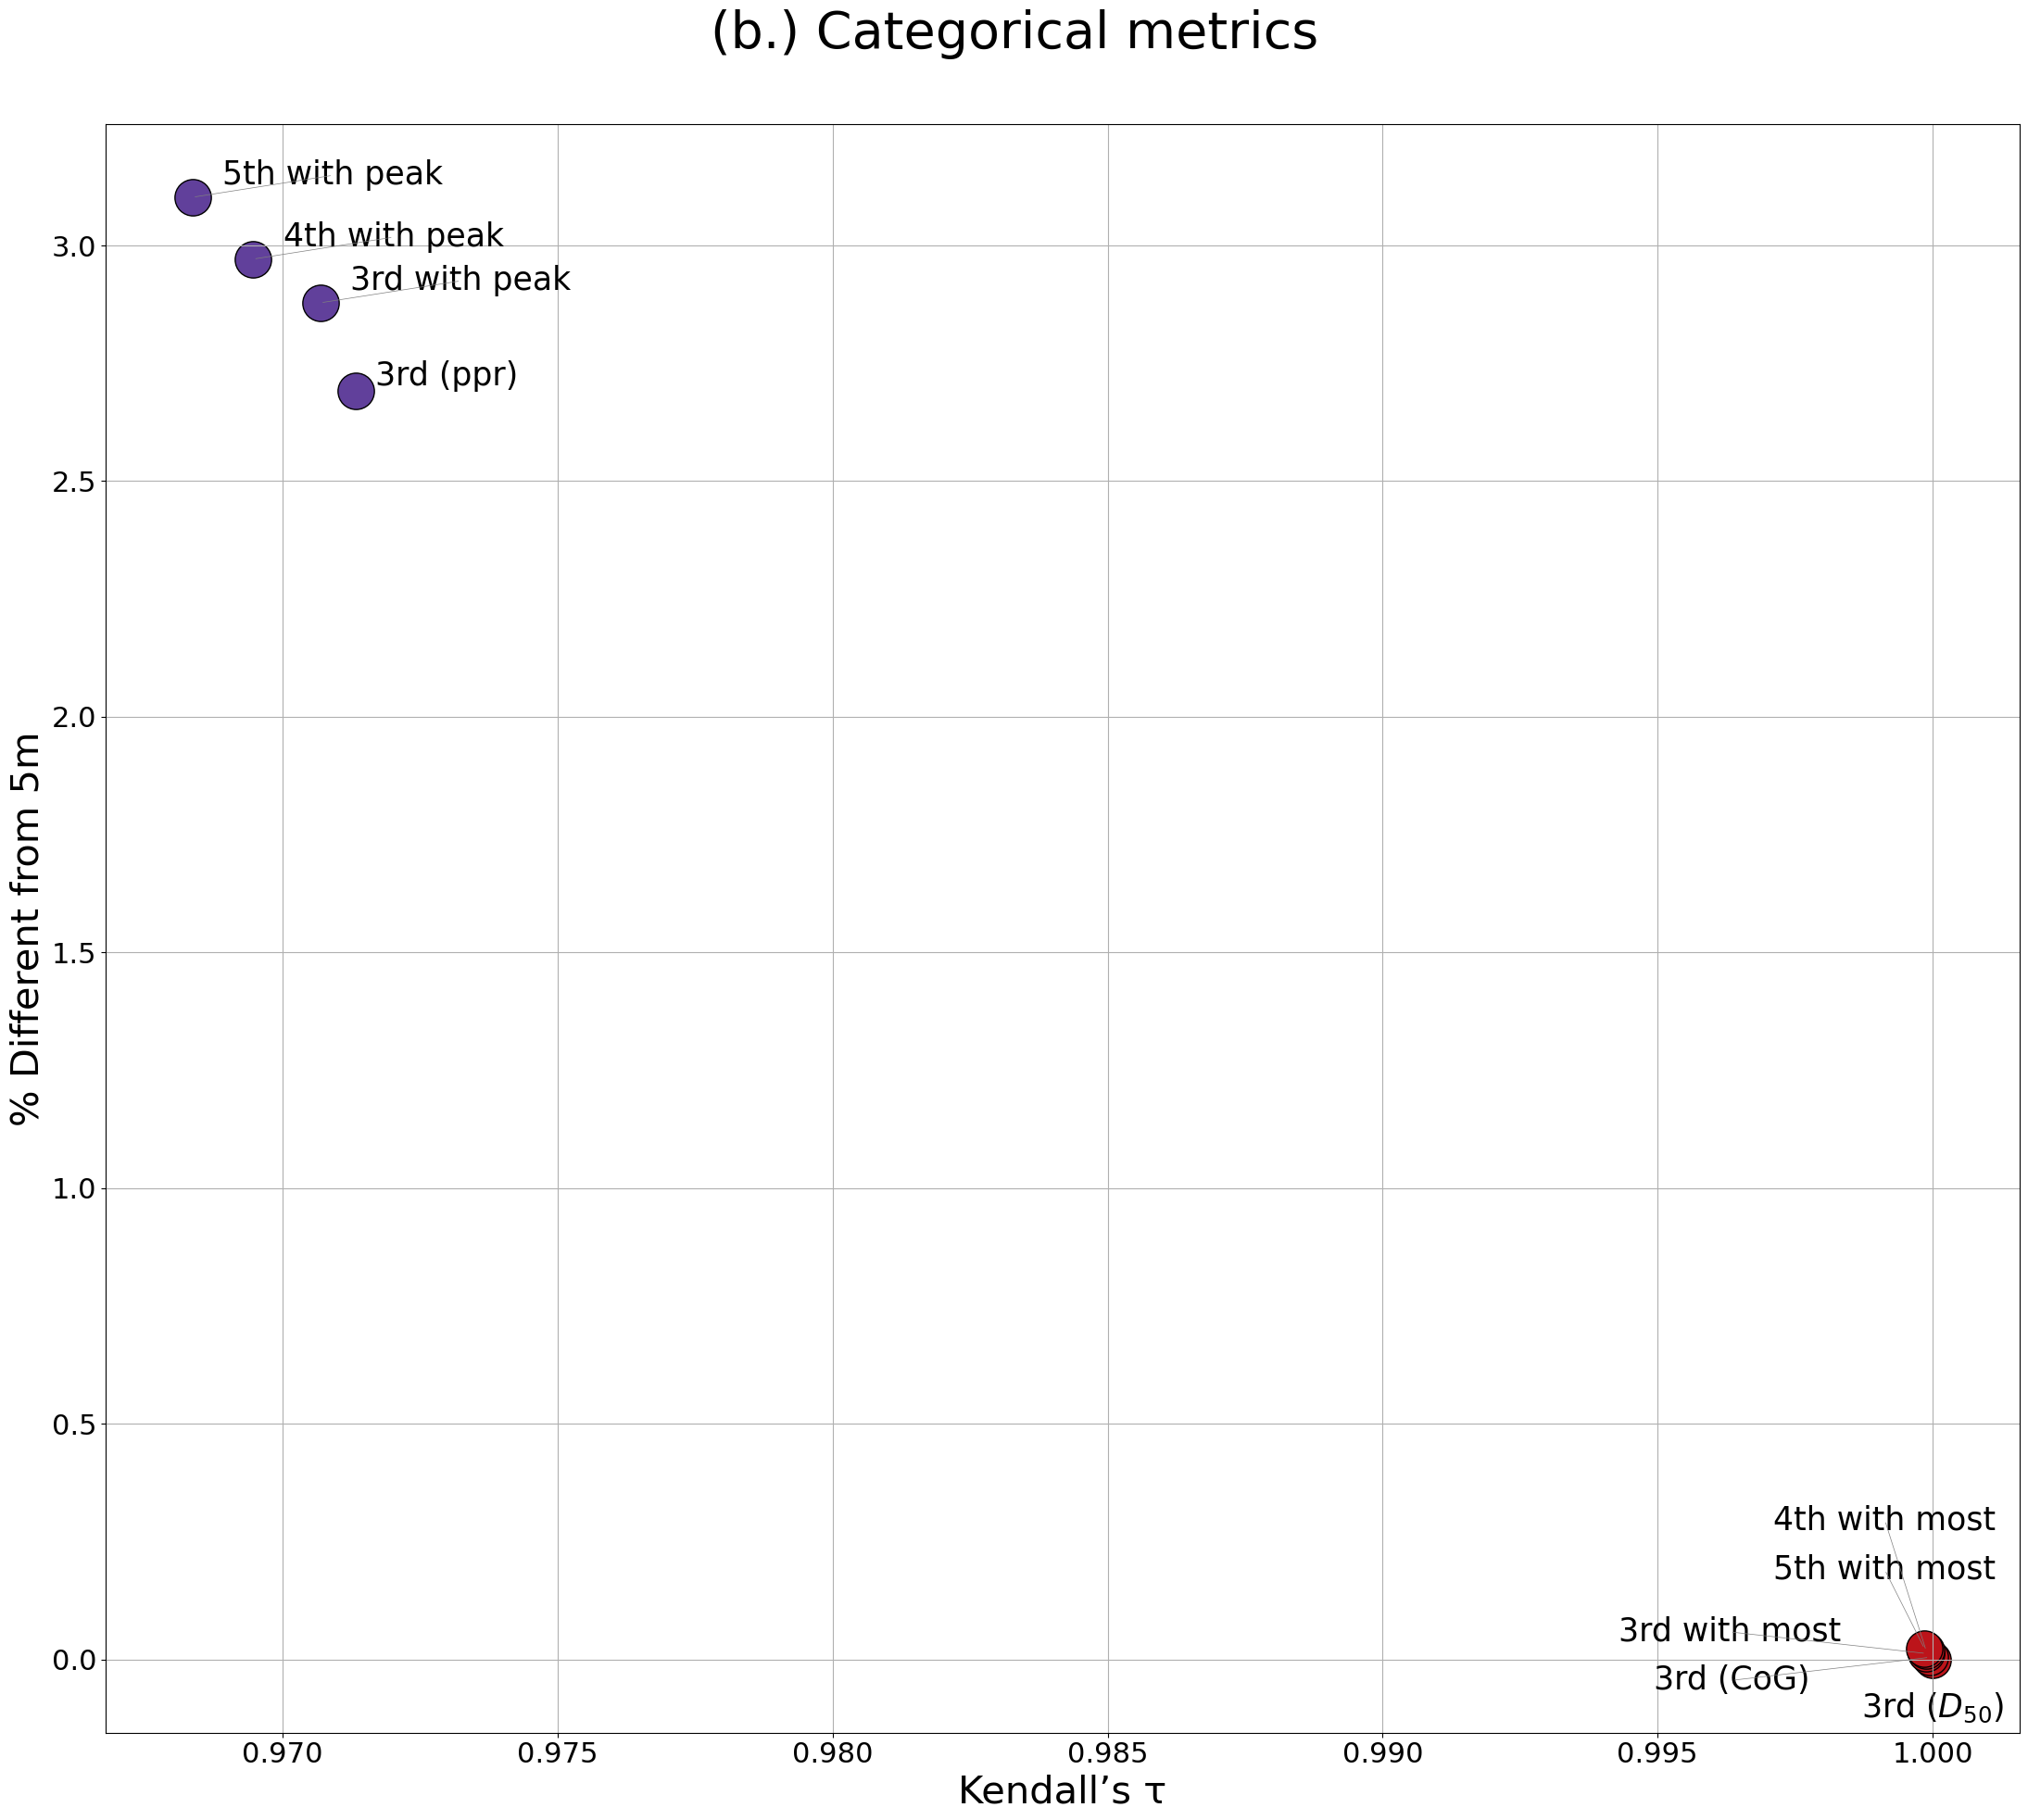

In [9]:
fig, ax = plt.subplots(figsize=(22, 20))  # Expanded canvas

marker = 'o'
size = 800
labelsize = 25
texts = []

for _, row in df_categorical.iterrows():
    # Scatter point
    ax.scatter(
        row["rank_corr"],
        row["val_diff"],
        facecolor=type_color_map_3[row['type2']][1],
        edgecolor='black',
        marker=marker,
        s=size,
        alpha=1)
    # Clean label name
    metric_name = name_mapping[row["metric"]]
    
    # Create text object (to be adjusted later)
    texts.append(
        ax.text(row["rank_corr"], row["val_diff"], metric_name, fontsize=labelsize))
ax.tick_params(axis='both', which='major', labelsize=22)
# Axes labels
ax.set_xlabel("Kendall’s τ", fontsize=30)
ax.set_ylabel("% Different from 5m", fontsize=30)
ax.grid(True)
# Adjust text to avoid overlaps
adjust_text(texts,
     ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.05, 1.2),
    expand_points=(1.2, 1.4),
    only_move={'points': 'xy', 'text': 'xy'},
    force_points=0.5,
    force_text=1.2)

fig.suptitle("(b.) Categorical metrics", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(figdir+ "CompareNormalisation/Scatter_categorical_dblnorm.png", dpi=300, facecolor='white', bbox_inches='tight')

## Legend

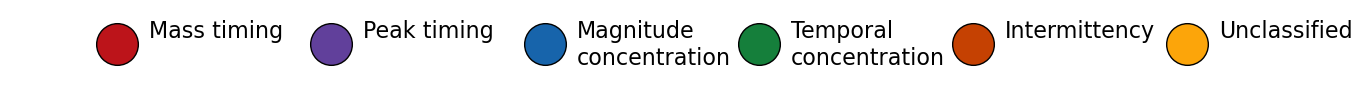

In [10]:
legend_types = list(type_color_map_3.keys())

# Create figure
fig, ax = plt.subplots(figsize=(14, 1))

# Plot circles and labels
for i, label in enumerate(legend_types):
    
    color = type_color_map_3[label][1]
    
    # Handle long titles
    title = label.replace(" ", "\n", 1) if len(label) > 20 else label
    if "\n" not in title:
        title = title + "\n "  # blank second line for spacing
    
    ax.scatter(i, 0, s=900, color=color, edgecolor='black')
    ax.text(i + 0.15, 0, title, va='center', fontsize=16)

# Remove axes
ax.set_xlim(-0.5, len(legend_types)-0.2)
ax.set_ylim(-0.5, 0.5)
ax.axis("off")

plt.tight_layout()

# Save if needed
plt.savefig(figdir + "CompareNormalisation/Scatter_dblnorm_legend.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

### Combine figures into one

In [11]:
from PIL import Image, ImageDraw, ImageFont
import math

def combine_images_grid(image_paths, out_path,
                        ncols=6, pad=10, bg_color=(255,255,255),
                        dpi=300, labels=None):
    imgs = [Image.open(p).convert("RGB") for p in image_paths]
    widths, heights = zip(*(i.size for i in imgs))
    cell_w = max(widths)
    cell_h = max(heights)

    n = len(imgs)
    nrows = -(-n // ncols)   # ceiling division
    out_w = ncols*cell_w + pad*(ncols+1)
    out_h = nrows*cell_h + pad*(nrows+1)
    canvas = Image.new("RGB", (out_w, out_h), bg_color)

    for idx, img in enumerate(imgs):
        r = idx // ncols
        c = idx % ncols
        x = pad + c*(cell_w + pad)
        y = pad + r*(cell_h + pad)
        # center image in cell
        img_w, img_h = img.size
        paste_x = x + (cell_w - img_w)//2
        paste_y = y + (cell_h - img_h)//2
        canvas.paste(img, (paste_x, paste_y))

        # optional label under the image
        if labels:
            draw = ImageDraw.Draw(canvas)
            try:
                font = ImageFont.truetype("DejaVuSans.ttf", 12)
            except Exception:
                font = ImageFont.load_default()
            text = labels[idx]
            tw, th = draw.textsize(text, font=font)
            draw.rectangle([paste_x, paste_y+img_h - th - 6, paste_x + tw + 6, paste_y+img_h],
                           fill=(255,255,255))
            draw.text((paste_x+3, paste_y+img_h - th - 4), text, fill=(0,0,0), font=font)

    # save (PNG or PDF). dpi metadata set to (dpi,dpi)
    canvas.save(out_path, dpi=(dpi, dpi))
    
# Collect all PNGs (adjust pattern/order as needed)
files = sorted(glob.glob(figdir + "CompareNormalisation/Scatter_continuous_dblnorm.png")) + \
        sorted(glob.glob(figdir + "CompareNormalisation/Scatter_categorical_dblnorm.png")) 

combine_images_grid(files, figdir+"CompareNormalisation/Scatter_combined_dblnorm.png", ncols=2, pad=12, dpi=300)